In [2]:
import os

os.environ["Tavily_API_KEY"] = os.getenv("TAVILY_API_KEY")

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq(model="openai/gpt-oss-120b")


In [1]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=5,
    topic ="general"
)

tavily_search_tool.invoke("What is current AI news?")

{'query': 'What is current AI news?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.artificialintelligence-news.com',
   'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
   'content': 'July 30, 2026\n\n### Google’s Gemini 3.6 Flash targets enterprise agent token costs\n\nAI in Action\n\nJuly 21, 2026\n\n### HP accelerates enterprise workflows with OpenAI Frontier\n\nWorld of Work\n\nJune 29, 2026\n\n#### Deep Learning\n\n### Aviva deploys AI to stop £230M in sophisticated insurance fraud\n\nAI in Action\n\nJune 8, 2026\n\n### China’s AI just mapped its entire renewable energy grid. Here’s why the rest of the world should pay attention\n\nEnvironment & Sustainability\n\nMay 22, 2026 [...] AI in Action\n\nJuly 21, 2026\n\n[](\n\n#### Enterprise\n\n### Red Hat, NVIDIA, IBM back project turning AI policy into code\n\nGovernance, Regulation & Policy\n\nAugust 4, 2026\n\n### Google’s Gemini 3.6 Flash targets ent

In [3]:
from langchain.tools import tool

@tool("calculator", description="A calculator that can perform basic arithmetic operations.")
def calc(expression: str) -> str:
        result = str(eval(expression))

In [4]:
from langchain.agents import create_agent

agent = create_agent(model, [tavily_search_tool, calc])

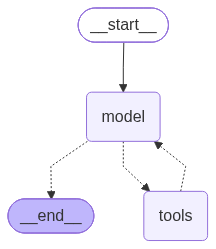

In [5]:
agent

In [6]:
user_input="What is current AI news for Anthropic and then calcualte 5+ 5"

for step in agent.stream(
    {"messages": user_input},
    stream_mode="values"
):
    step["messages"][-1].pretty_print()


================================ Human Message =================================

What is current AI news for Anthropic and then calcualte 5+ 5
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_54c37477-2f3d-455b-8848-dd51f77a3d91)
 Call ID: fc_54c37477-2f3d-455b-8848-dd51f77a3d91
  Args:
    query: latest AI news Anthropic 2024
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news Anthropic 2024", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.synapnews.com/articles/anthropic-claude-ai-defense", "title": "Anthropic: Claude AI, Defense Control & AI Equity 2024 | SynapNews", "content": "In 2024, the Artificial Intelligence (AI) landscape is a dynamic arena where technological innovation meets high-stakes geopolitical strategy and unprecedented financial opportu

In [7]:
agent.invoke({"messages": "What is current ai news "})['messages'][-1].content

'**Current AI‑related headlines (late\u202fJuly\u202f–\u202fearly\u202fAugust\u202f2024)**  \n\n| Date | Source | Headline & Key Take‑aways |\n|------|--------|---------------------------|\n| **Aug\u202f15\u202f2024** | *AI\u202fBusiness* | **Explainable AI** – Companies are racing to add transparent, “explain‑able” layers to large language models (LLMs) to meet upcoming regulator expectations and to win customer trust. |\n| **Aug\u202f14\u202f2024** | *AI\u202fBusiness* | **Yoshua\u202fBengio joins AI‑Safety standards project** – The Turing‑Award winner has signed on to a multi‑stakeholder effort (including the EU, ISO and major labs) to draft concrete safety standards for foundation models. |\n| **Aug\u202f14\u202f2024** | *AI\u202fBusiness* | **Female leadership in AI** – A feature on three women executives who are shaping AI strategy in finance, health‑tech and cloud services, underscoring the industry’s push for diversity. |\n| **Aug\u202f8\u202f2024** | *AI\u202fBusiness* | **“Fe